# Polar plot
Based on https://github.com/climberlenny/test_openberg/blob/main/toolbox/postprocessing.py

In [1]:
cd ~/work/tutorials/sources/OpenDrift/openberg_july2026

/home/jovyan/work/tutorials/sources/OpenDrift/openberg_july2026


In [2]:
from src.utils import *
from openberg_july2026.src2.utils0 import *
from openberg_july2026.src2.utils2 import *
from openberg_july2026.src2.utils3 import *
import glob

In [3]:
# Read and subset tracker data
ib = 'iceberg2025w'
#read obs
fname = 'merged_obs10'#'merged_obs_iceberg2026e_3D'
with xr.open_dataset('./input/%s.nc'%fname) as ds:
    obs = ds.sel(iceberg=ib,trajectory_id=ib) 
    obs_seed = obs.isel(time=(obs.seed_idx==1))

In [40]:
#read sim
file_contain_all = [ib,]
file_contain_any = ['_']
file_notcontain = ['test','prof','next','idx']#'test','wa','next','glorys']#['topaz4','glorys','slope','era5','almost','stokes',]
file_l = glob.glob("./results/%s/*.nc"%ib)#['./results/juliette_topaz6_topaz4_windglophynrt.nc',]
file_l = [f for f in file_l if all(ff in f for ff in file_contain_all)] #filtering for required keywords
file_l = [f for f in file_l if any(ff in f for ff in file_contain_any)] #filtering for required keywords
file_l = [f for f in file_l if all(ff not in f for ff in file_notcontain)] #filtering for neglected keywords
# file_l = file_l[::-1]
print(file_l)

['./results/iceberg2025w/iceberg2025w_gebco_glophyanfcH_glophyanfcD_windglophynrt_newcoefmix_joined.nc', './results/iceberg2025w/iceberg2025w_gebco_topaz5_windglophynrt_newcoefmix_joined.nc', './results/iceberg2025w/iceberg2025w_gebco_topaz4_windglophynrt_newcoefmix_joined.nc', './results/iceberg2025w/iceberg2025w_gebco_glorys_windglophynrt_newcoefmix_joined.nc', './results/iceberg2025w/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_newcoefmix_full_joined.nc']


In [41]:
#dicts and definitions
legenddict = dict.fromkeys([f.split('/')[-1][:-3] for f in file_l])
for f in legenddict:
    ll = []
    for l in legenddict_full:
        if (l!='ICEBERG') and (l.lower() in f.lower()): ll = ll+[l]  
    legenddict[f]={'col':legenddict_full[ll[-1]]['col'], 'alpha':1, 'kw':', '.join(ll),'zo':legenddict_full[ll[-1]]['zo'],
                 'traj':np.arange(obs.time.size*11)}
#manual adaptions
# legenddict['iceberg2018b_gebco_topaz4_windglophyre']['zo']=25
# legenddict['iceberg2011w1_gebco_nextsimre_topaz4_arcmfcwamre_windglophyre_newocefmix_joined']['col']='pink'
# legenddict['iceberg2011w1_gebco_nextsimre_glorys_windglophyre_newcoefmix_joined']['zo']=18
# legenddict['iceberg2011w1_gebco_nextsimre_topaz4_windglophyre_newcoefmix_joined']['zo']=18

legenddict 

{'iceberg2025w_gebco_glophyanfcH_glophyanfcD_windglophynrt_newcoefmix_joined': {'col': 'darkseagreen',
  'alpha': 1,
  'kw': 'WINDGLOPHYNRT, GLOPHYANFCH, GLOPHYANFCD',
  'zo': 21,
  'traj': array([   0,    1,    2, ..., 2747, 2748, 2749], shape=(2750,))},
 'iceberg2025w_gebco_topaz5_windglophynrt_newcoefmix_joined': {'col': 'cornflowerblue',
  'alpha': 1,
  'kw': 'WINDGLOPHYNRT, TOPAZ5',
  'zo': 23,
  'traj': array([   0,    1,    2, ..., 2747, 2748, 2749], shape=(2750,))},
 'iceberg2025w_gebco_topaz4_windglophynrt_newcoefmix_joined': {'col': 'darkslateblue',
  'alpha': 1,
  'kw': 'WINDGLOPHYNRT, TOPAZ4',
  'zo': 22,
  'traj': array([   0,    1,    2, ..., 2747, 2748, 2749], shape=(2750,))},
 'iceberg2025w_gebco_glorys_windglophynrt_newcoefmix_joined': {'col': 'darkolivegreen',
  'alpha': 1,
  'kw': 'WINDGLOPHYNRT, GLORYS',
  'zo': 20,
  'traj': array([   0,    1,    2, ..., 2747, 2748, 2749], shape=(2750,))},
 'iceberg2025w_gebco_topaz6_topaz5_windglophynrt_newcoefmix_full_joined': {'

In [42]:
try: #if not joined
    simall = xr.open_mfdataset(file_l,concat_dim="run",combine="nested")
    simall = simall.assign_coords(run=list(legenddict.keys()))
except:     #if joined already
    simall = xr.open_mfdataset(file_l) 
    #then adjust legenddict as well
    legenddict = dict.fromkeys([str(f) for f in simall.run.values])
    for f in legenddict:
        ll = []
        for l in legenddict_full:
            if l.lower() in f: ll = ll+[l]
        legenddict[f]={'col':legenddict_full[ll[-1]]['col'], 'alpha':1, 'kw':', '.join(ll),'zo':legenddict_full[ll[-1]]['zo'],
                     'traj':np.arange(obs.time.size*11)}

In [43]:
# --- Subset---
apn = dict_analysis_period[ib]['full']

# ---Trajectory subset
sim = simall
if ib in dict_traj.keys():
    for run in list(sim.run.values):
        if run in dict_traj[ib]: 
            sim = sim.sel(trajectory=dict_traj[ib][run])
            print('Trajectory subset applied on ',run)

# ---Time subset
if apn!=None: 
    sim = sim.sel(time=apn)
    print('Time subset applied: ',apn)

# ---time frequnecy subset
days = obs.time.dt.floor("D")
days2 = np.arange(obs_seed.time.dt.floor("D")[0].values,
                  obs_seed.time.dt.floor("D")[-1].values+np.timedelta64(str(obs.seed_freq.values)[:-1],str(obs.seed_freq.values)[-1]),
                  dtype='datetime64[D]')
idx = [
    np.where(days == np.datetime64(d))[0][0]
    for d in days2
    if (days == np.datetime64(d)).any()
]
obs_subtime = obs.isel(time=idx)
sim_obssubtime = sim.sel(time=obs_subtime.time, method="nearest") 

sim_sub = sim_obssubtime
obs_sub = obs_subtime

Time subset applied:  slice('2025-10-11', '2025-12-10', None)


iceberg2025w_gebco_glophyanfcH_glophyanfcD_windglophynrt_newcoefmix_joined 0 142 0 142 darkseagreen
iceberg2025w_gebco_topaz5_windglophynrt_newcoefmix_joined 0 142 0 142 cornflowerblue
iceberg2025w_gebco_topaz4_windglophynrt_newcoefmix_joined 0 142 0 142 darkslateblue
iceberg2025w_gebco_glorys_windglophynrt_newcoefmix_joined 0 142 0 142 darkolivegreen
iceberg2025w_gebco_topaz6_topaz5_windglophynrt_newcoefmix_full_joined 0 142 0 142 turquoise


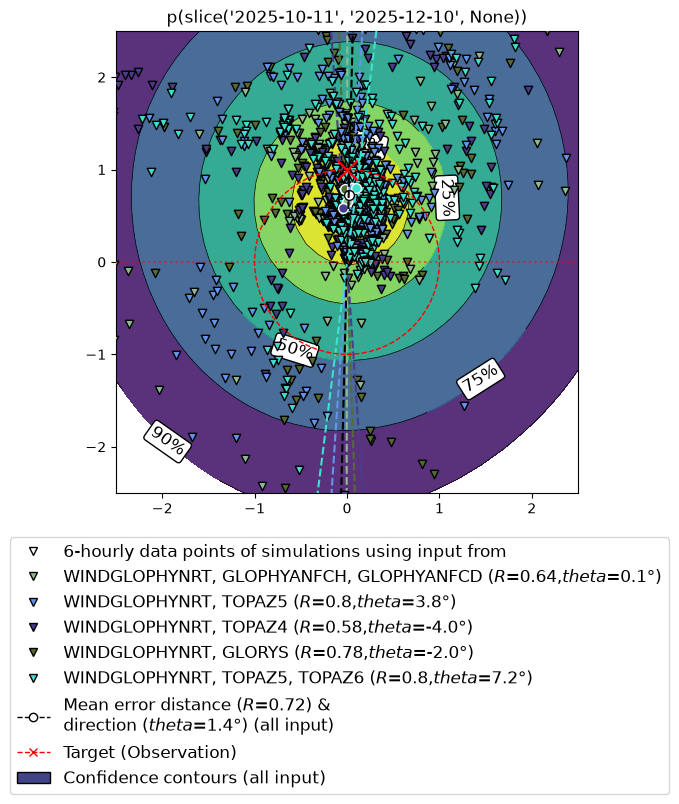

In [44]:
# del polarplot_m
# from openberg_july2026.src2.utils3 import polarplot_m
out = polarplot_m(sim_sub,obs_sub,legenddict,title='p(%s)'%apn)

In [9]:
#means
[{k:(float(v[0]),int(np.round(v[1])))} for k,v in out['mean'].items() if k != 'all']

[{'iceberg2025w_gebco_glophyanfcH_glophyanfcD_windglophynrt_newcoefmix_joined': (0.64,
   0)},
 {'iceberg2025w_gebco_topaz5_windglophynrt_newcoefmix_joined': (0.8, 4)},
 {'iceberg2025w_gebco_topaz4_windglophynrt_newcoefmix_joined': (0.58, -4)},
 {'iceberg2025w_gebco_glorys_windglophynrt_newcoefmix_joined': (0.78, -2)}]

In [10]:
#spreads
[{k:(float(v[1]),int(np.round(v[-1])))} for k,v in out['spread'].items() if k != 'all']

[{'iceberg2025w_gebco_glophyanfcH_glophyanfcD_windglophynrt_newcoefmix_joined': (2.29,
   115)},
 {'iceberg2025w_gebco_topaz5_windglophynrt_newcoefmix_joined': (1.92, 134)},
 {'iceberg2025w_gebco_topaz4_windglophynrt_newcoefmix_joined': (2.21, 104)},
 {'iceberg2025w_gebco_glorys_windglophynrt_newcoefmix_joined': (2.45, 108)}]

In [11]:
out

{'mean': {'all': [np.float64(0.7), np.float64(-0.27)],
  'iceberg2025w_gebco_glophyanfcH_glophyanfcD_windglophynrt_newcoefmix_joined': [np.float64(0.64),
   np.float64(0.08)],
  'iceberg2025w_gebco_topaz5_windglophynrt_newcoefmix_joined': [np.float64(0.8),
   np.float64(3.83)],
  'iceberg2025w_gebco_topaz4_windglophynrt_newcoefmix_joined': [np.float64(0.58),
   np.float64(-3.95)],
  'iceberg2025w_gebco_glorys_windglophynrt_newcoefmix_joined': [np.float64(0.78),
   np.float64(-1.95)]},
 'spread': {'all': [np.float64(5.97),
   np.float64(2.26),
   np.float64(355.54),
   np.float64(112.74)],
  'iceberg2025w_gebco_glophyanfcH_glophyanfcD_windglophynrt_newcoefmix_joined': [np.float64(5.96),
   np.float64(2.29),
   np.float64(350.32),
   np.float64(115.2)],
  'iceberg2025w_gebco_topaz5_windglophynrt_newcoefmix_joined': [np.float64(4.33),
   np.float64(1.92),
   np.float64(317.39),
   np.float64(133.71)],
  'iceberg2025w_gebco_topaz4_windglophynrt_newcoefmix_joined': [np.float64(5.35),
   np.